In [1]:
import sys
import os
from pathlib import Path
import torch

import numpy as np

PROJECT_ROOT = Path.cwd().parent
print(f"Project root: {PROJECT_ROOT}")
sys.path.insert(0, str(PROJECT_ROOT))
os.chdir(PROJECT_ROOT)

from src.training.setup import get_dataloaders, setup_experiment
from src.utils.scale import inverse_target


def rmse_per_horizon(y_true: torch.Tensor, y_pred: torch.Tensor) -> torch.Tensor:
    # y_*: [N, H]
    return torch.sqrt(torch.mean((y_pred - y_true) ** 2, dim=0))  # [H]

def calc_smape_errors(y_pred, y_true, epsilon=1e-10):
    numerator = np.abs(y_pred - y_true)
    denominator = (np.abs(y_pred) + np.abs(y_true)) / 2.0
    return 100 * (numerator / (denominator + epsilon))

def bootstrap_ci_per_horizon(errors_by_sample: np.ndarray, n_boot=300, alpha=0.05, seed=0):
    """
    errors_by_sample: shape [N, H] = per-sample absolute error etc.
    returns: mean [H], lo [H], hi [H]
    """
    rng = np.random.default_rng(seed)
    N, H = errors_by_sample.shape

    boots = np.empty((n_boot, H), dtype=float)
    for b in range(n_boot):
        idx = rng.integers(0, N, size=N)
        boots[b] = errors_by_sample[idx].mean(axis=0)

    mean = errors_by_sample.mean(axis=0)
    lo = np.quantile(boots, alpha/2, axis=0)
    hi = np.quantile(boots, 1-alpha/2, axis=0)
    return mean, lo, hi

@torch.no_grad()
def predict_all(model, loader, device):
    ys, ps = [], []
    for x, y in loader:
        x = x.to(device)
        y = y.to(device)
        pred = model(x)
        ys.append(y)
        ps.append(pred)
    return torch.cat(ys, dim=0), torch.cat(ps, dim=0)

@torch.no_grad()
def predict_persistence(test_loader, device, feature_idx=0):
    """
    Persistence baseline:
    predict last observed value of the TARGET FEATURE for all horizon steps.
    """
    ys, ps = [], []

    for x, y in test_loader:
        x = x.to(device)
        y = y.to(device)
    
        last_val = x[:, -1, feature_idx] 
        H = y.shape[1]
        pred = last_val.unsqueeze(1).repeat(1, H)

        ys.append(y)
        ps.append(pred)

    return torch.cat(ys, dim=0), torch.cat(ps, dim=0)




Project root: /Users/arthurreuss/code/Arthurreuss/Python/RUG/AIE/NO2_Prediction


/Users/arthurreuss/code/Arthurreuss/Python/RUG/AIE/NO2_Prediction/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026/01/28 20:58:54 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/01/28 20:58:54 INFO mlflow.store.db.utils: Updating database tables
2026/01/28 20:58:54 INFO alembic.runtime.migration: Context impl SQLiteImpl.
2026/01/28 20:58:54 INFO alembic.runtime.migration: Will assume non-transactional DDL.
2026/01/28 20:58:54 INFO alembic.runtime.migration: Context impl SQLiteImpl.
2026/01/28 20:58:54 INFO alembic.runtime.migration: Will assume non-transactional DDL.
2026/01/28 20:58:54 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/01/28 20:58:54 INFO mlflow.store.db.utils: Updating database tables
2026/01/28 20:58:54 INFO alembic.runti

[device] Using MPS
Using feature index 10 ('nitrogen_dioxide') for Persistence.


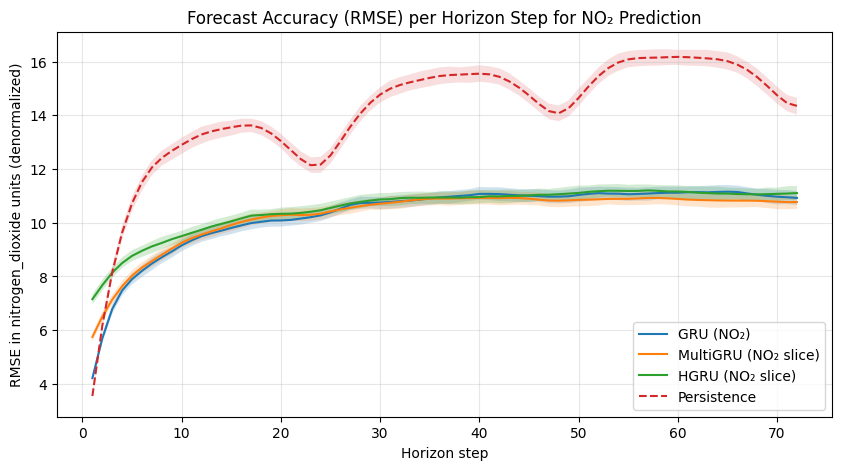

In [2]:

import matplotlib.pyplot as plt
import numpy as np
from src.utils.helper import load_torch_model_from_registry

GRU_MODEL_NAME = "gru_best_model"
MULTIGRU_MODEL_NAME = "multigru_best_model"
HGRU_MODEL_NAME = "hgru_best_model"

ctx = setup_experiment("configs/config_training.yaml", experiment_name="Plotting")
cfg = ctx["cfg"]
device = ctx["device"]

numeric_cols = ctx["numeric_cols"]
scaler = ctx["scaler"]

plot_target = "nitrogen_dioxide"

_, _, test_loader_single = get_dataloaders(cfg, multi_target=False)
_, _, test_loader_multi = get_dataloaders(cfg, multi_target=True)

gru = load_torch_model_from_registry(GRU_MODEL_NAME, device)
multigru = load_torch_model_from_registry(MULTIGRU_MODEL_NAME, device)
hgru = load_torch_model_from_registry(HGRU_MODEL_NAME, device)

feature_cols = cfg["data"]["feature_cols"]
target_feat_idx = feature_cols.index(plot_target)
print(f"Using feature index {target_feat_idx} ('{plot_target}') for Persistence.")

y_true_s, y_pred_gru = predict_all(gru, test_loader_single, device)
y_true_m, y_pred_mgru = predict_all(multigru, test_loader_multi, device)
y_true_h, y_pred_hgru = predict_all(hgru, test_loader_multi, device)
y_true_p, y_pred_persist = predict_persistence(test_loader_single, device, feature_idx=target_feat_idx)

t_idx = cfg["data"]["target_cols"].index(plot_target)

y_true_den_s = inverse_target(scaler, y_true_s, numeric_cols, plot_target)
y_true_den_m = inverse_target(scaler, y_true_m[..., t_idx], numeric_cols, plot_target)

y_gru_den = inverse_target(scaler, y_pred_gru, numeric_cols, plot_target)
y_mgru_den = inverse_target(scaler, y_pred_mgru[..., t_idx], numeric_cols, plot_target)
y_hgru_den = inverse_target(scaler, y_pred_hgru[..., t_idx], numeric_cols, plot_target)
y_persist_den = inverse_target(scaler, y_pred_persist, numeric_cols, plot_target)

err_gru_sq = (y_gru_den - y_true_den_s) ** 2
err_mgru_sq = (y_mgru_den - y_true_den_m) ** 2
err_hgru_sq = (y_hgru_den - y_true_den_m) ** 2
err_persist_sq = (y_persist_den - y_true_den_s) ** 2

err_gru_sq = err_gru_sq.detach().cpu().numpy()
err_mgru_sq = err_mgru_sq.detach().cpu().numpy()
err_hgru_sq = err_hgru_sq.detach().cpu().numpy()
err_persist_sq = err_persist_sq.detach().cpu().numpy()

mse_gru, mse_lo_gru, mse_hi_gru = bootstrap_ci_per_horizon(err_gru_sq, n_boot=300)
mse_mgru, mse_lo_mgru, mse_hi_mgru = bootstrap_ci_per_horizon(err_mgru_sq, n_boot=300)
mse_hgru, mse_lo_hgru, mse_hi_hgru = bootstrap_ci_per_horizon(err_hgru_sq, n_boot=300)
mse_persist, mse_lo_persist, mse_hi_persist = bootstrap_ci_per_horizon(err_persist_sq, n_boot=300)

mean_gru, lo_gru, hi_gru = np.sqrt(mse_gru), np.sqrt(mse_lo_gru), np.sqrt(mse_hi_gru)
mean_mgru, lo_mgru, hi_mgru = np.sqrt(mse_mgru), np.sqrt(mse_lo_mgru), np.sqrt(mse_hi_mgru)
mean_hgru, lo_hgru, hi_hgru = np.sqrt(mse_hgru), np.sqrt(mse_lo_hgru), np.sqrt(mse_hi_hgru)
mean_persist, lo_persist, hi_persist = np.sqrt(mse_persist), np.sqrt(mse_lo_persist), np.sqrt(mse_hi_persist)

H = len(mean_gru)
h = np.arange(1, H + 1)

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(h, mean_gru, label="GRU (NO₂)")
ax.fill_between(h, lo_gru, hi_gru, alpha=0.2)

ax.plot(h, mean_mgru, label="MultiGRU (NO₂ slice)")
ax.fill_between(h, lo_mgru, hi_mgru, alpha=0.2)

ax.plot(h, mean_hgru, label="HGRU (NO₂ slice)")
ax.fill_between(h, lo_hgru, hi_hgru, alpha=0.2)

ax.plot(h, mean_persist, label="Persistence", linestyle="--")
ax.fill_between(h, lo_persist, hi_persist, alpha=0.15)

ax.set_xlabel("Horizon step")
ax.set_ylabel(f"RMSE in {plot_target} units (denormalized)")
ax.set_title("Forecast Accuracy (RMSE) per Horizon Step for NO₂ Prediction")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

/var/folders/wt/1p1d6dz50_d27htd1hwwlyv00000gn/T/ipykernel_79291/1690874114.py:22: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  numerator = np.abs(y_pred - y_true)
/var/folders/wt/1p1d6dz50_d27htd1hwwlyv00000gn/T/ipykernel_79291/1690874114.py:23: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  denominator = (np.abs(y_pred) + np.abs(y_true)) / 2.0


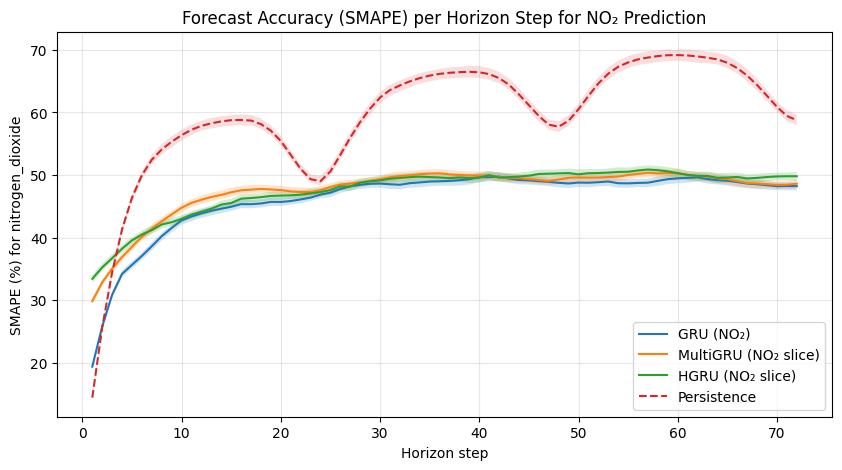

In [ ]:
err_gru_smape = calc_smape_errors(y_gru_den, y_true_den_s)
err_mgru_smape = calc_smape_errors(y_mgru_den, y_true_den_m)
err_hgru_smape = calc_smape_errors(y_hgru_den, y_true_den_m)
err_persist_smape = calc_smape_errors(y_persist_den, y_true_den_s)


smape_gru, lo_gru_s, hi_gru_s = bootstrap_ci_per_horizon(err_gru_smape, n_boot=300)
smape_mgru, lo_mgru_s, hi_mgru_s = bootstrap_ci_per_horizon(err_mgru_smape, n_boot=300)
smape_hgru, lo_hgru_s, hi_hgru_s = bootstrap_ci_per_horizon(err_hgru_smape, n_boot=300)
smape_persist, lo_persist_s, hi_persist_s = bootstrap_ci_per_horizon(err_persist_smape, n_boot=300)

fig, ax = plt.subplots(figsize=(10, 5))
H = len(smape_gru)
h = np.arange(1, H + 1)

ax.plot(h, smape_gru, label="GRU (NO₂)")
ax.fill_between(h, lo_gru_s, hi_gru_s, alpha=0.2)

ax.plot(h, smape_mgru, label="MultiGRU (NO₂ slice)")
ax.fill_between(h, lo_mgru_s, hi_mgru_s, alpha=0.2)

ax.plot(h, smape_hgru, label="HGRU (NO₂ slice)")
ax.fill_between(h, lo_hgru_s, hi_hgru_s, alpha=0.2)

ax.plot(h, smape_persist, label="Persistence", linestyle="--")
ax.fill_between(h, lo_persist_s, hi_persist_s, alpha=0.15)

ax.set_xlabel("Horizon step")
ax.set_ylabel(f"SMAPE (%) for {plot_target}")
ax.set_title("Forecast Accuracy (SMAPE) per Horizon Step for NO₂ Prediction")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

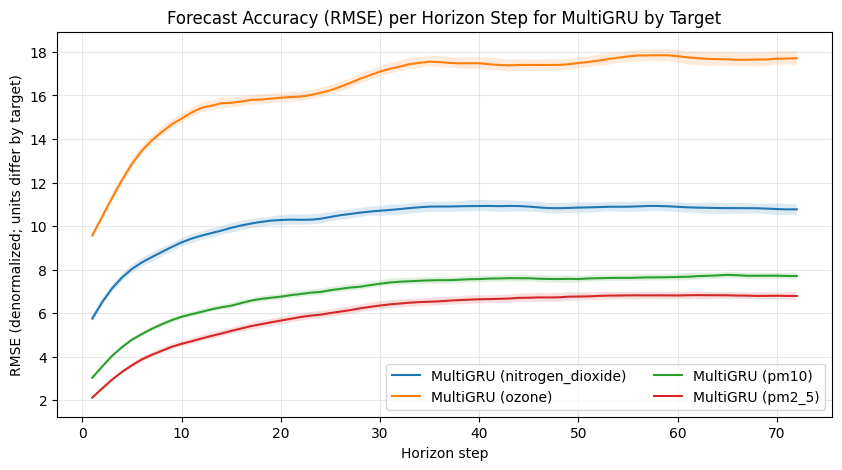

In [5]:
# MultiGRU: per-target bootstrap bands (denormalized per target)
H = y_true_m.shape[1]
h = np.arange(1, H + 1)

fig, ax = plt.subplots(figsize=(10, 5))

for col_name in cfg["data"]["target_cols"]:
    j = cfg["data"]["target_cols"].index(col_name)

    y_true_j = y_true_m[..., j]
    y_pred_j = y_pred_mgru[..., j]

    y_true_j_den = inverse_target(scaler, y_true_j, numeric_cols, col_name)
    y_pred_j_den = inverse_target(scaler, y_pred_j, numeric_cols, col_name)


    err_samples_sq = (y_pred_j_den - y_true_j_den) ** 2
    err_samples_sq = err_samples_sq.detach().cpu().numpy()
    
    mse_mean, mse_lo, mse_hi = bootstrap_ci_per_horizon(err_samples_sq, n_boot=300)

    rmse_mean = np.sqrt(mse_mean)
    rmse_lo   = np.sqrt(mse_lo)
    rmse_hi   = np.sqrt(mse_hi)

    ax.plot(h, rmse_mean, label=f"MultiGRU ({col_name})")
    ax.fill_between(h, rmse_lo, rmse_hi, alpha=0.15)

ax.set_xlabel("Horizon step")
ax.set_ylabel("RMSE (denormalized; units differ by target)")
ax.set_title("Forecast Accuracy (RMSE) per Horizon Step for MultiGRU by Target")
ax.grid(True, alpha=0.3)
ax.legend(ncol=2)
plt.show()

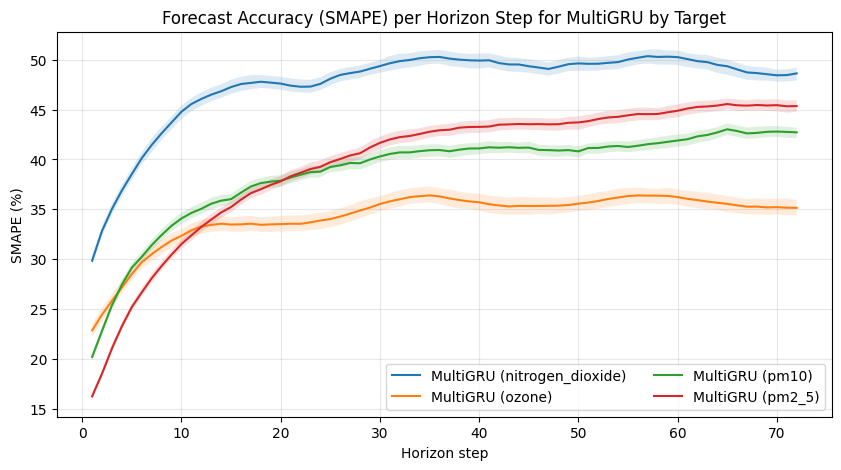

In [ ]:
# MultiGRU: per-target bootstrap bands (SMAPE)
H = y_true_m.shape[1]
h = np.arange(1, H + 1)

fig, ax = plt.subplots(figsize=(10, 5))

for col_name in cfg["data"]["target_cols"]:
    j = cfg["data"]["target_cols"].index(col_name)

    y_true_j = y_true_m[..., j]
    y_pred_j = y_pred_mgru[..., j]

    y_true_j_den = inverse_target(scaler, y_true_j, numeric_cols, col_name)
    y_pred_j_den = inverse_target(scaler, y_pred_j, numeric_cols, col_name)

    if hasattr(y_true_j_den, "detach"):
        y_true_j_den = y_true_j_den.detach().cpu().numpy()
    if hasattr(y_pred_j_den, "detach"):
        y_pred_j_den = y_pred_j_den.detach().cpu().numpy()

    numerator = np.abs(y_pred_j_den - y_true_j_den)
    denominator = (np.abs(y_pred_j_den) + np.abs(y_true_j_den)) / 2.0
    epsilon = 1e-10
    
    err_samples_smape = 100 * (numerator / (denominator + epsilon))
    
    smape_mean, smape_lo, smape_hi = bootstrap_ci_per_horizon(err_samples_smape, n_boot=300)

    ax.plot(h, smape_mean, label=f"MultiGRU ({col_name})")
    ax.fill_between(h, smape_lo, smape_hi, alpha=0.15)

ax.set_xlabel("Horizon step")
ax.set_ylabel("SMAPE (%)")
ax.set_title("Forecast Accuracy (SMAPE) per Horizon Step for MultiGRU by Target")
ax.grid(True, alpha=0.3)
ax.legend(ncol=2)
plt.show()

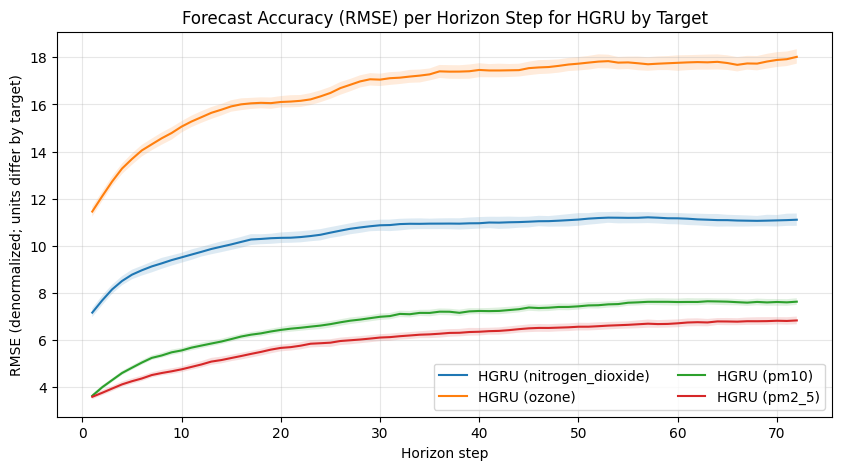

In [11]:
# HGRU: per-target bootstrap bands (denormalized per target)
H = y_true_h.shape[1]
h = np.arange(1, H + 1)

fig, ax = plt.subplots(figsize=(10, 5))

for col_name in cfg["data"]["target_cols"]:
    j = cfg["data"]["target_cols"].index(col_name)

    y_true_j = y_true_h[..., j]
    y_pred_j = y_pred_hgru[..., j]

    y_true_j_den = inverse_target(scaler, y_true_j, numeric_cols, col_name)
    y_pred_j_den = inverse_target(scaler, y_pred_j, numeric_cols, col_name)

    err_samples_sq = (y_pred_j_den - y_true_j_den) ** 2
    err_samples_sq = err_samples_sq.detach().cpu().numpy()
    
    mse_mean, mse_lo, mse_hi = bootstrap_ci_per_horizon(err_samples_sq, n_boot=300)
    rmse_mean = np.sqrt(mse_mean)
    rmse_lo   = np.sqrt(mse_lo)
    rmse_hi   = np.sqrt(mse_hi)

    ax.plot(h, rmse_mean, label=f"HGRU ({col_name})")
    ax.fill_between(h, rmse_lo, rmse_hi, alpha=0.15)

ax.set_xlabel("Horizon step")
ax.set_ylabel("RMSE (denormalized; units differ by target)")
ax.set_title("Forecast Accuracy (RMSE) per Horizon Step for HGRU by Target")
ax.grid(True, alpha=0.3)
ax.legend(ncol=2)
plt.show()

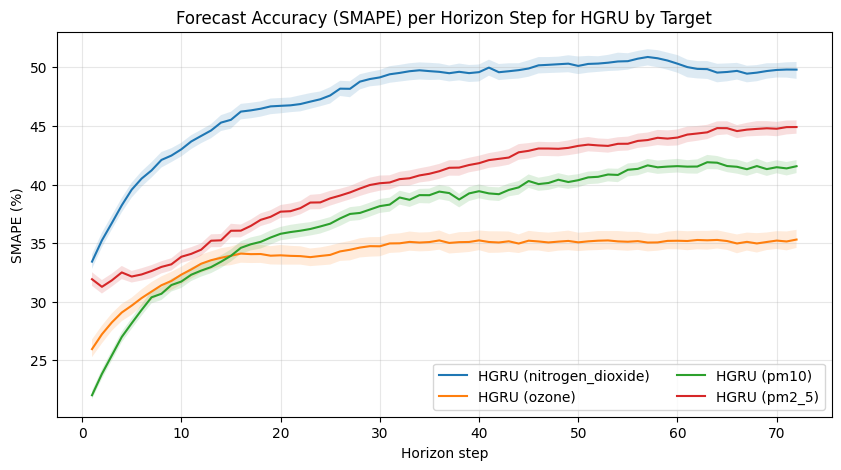

In [ ]:
# HGRU: per-target bootstrap bands (SMAPE)
H = y_true_h.shape[1]
h = np.arange(1, H + 1)

fig, ax = plt.subplots(figsize=(10, 5))

for col_name in cfg["data"]["target_cols"]:
    j = cfg["data"]["target_cols"].index(col_name)

    y_true_j = y_true_h[..., j]
    y_pred_j = y_pred_hgru[..., j]

    y_true_j_den = inverse_target(scaler, y_true_j, numeric_cols, col_name)
    y_pred_j_den = inverse_target(scaler, y_pred_j, numeric_cols, col_name)

    if hasattr(y_true_j_den, "detach"):
        y_true_j_den = y_true_j_den.detach().cpu().numpy()
    if hasattr(y_pred_j_den, "detach"):
        y_pred_j_den = y_pred_j_den.detach().cpu().numpy()

    numerator = np.abs(y_pred_j_den - y_true_j_den)
    denominator = (np.abs(y_pred_j_den) + np.abs(y_true_j_den)) / 2.0
    epsilon = 1e-10
    
    err_samples_smape = 100 * (numerator / (denominator + epsilon))

    smape_mean, smape_lo, smape_hi = bootstrap_ci_per_horizon(err_samples_smape, n_boot=300)

    ax.plot(h, smape_mean, label=f"HGRU ({col_name})")
    ax.fill_between(h, smape_lo, smape_hi, alpha=0.15)

ax.set_xlabel("Horizon step")
ax.set_ylabel("SMAPE (%)")
ax.set_title("Forecast Accuracy (SMAPE) per Horizon Step for HGRU by Target")
ax.grid(True, alpha=0.3)
ax.legend(ncol=2)
plt.show()

In [13]:
import os
import numpy as np

def save_model_errors(model_name, y_pred_den, y_true_den, save_dir="results/errors"):
    """
    Calculates and saves squared errors (for RMSE) and SMAPE errors.
    Converts tensors to numpy if needed.
    """
    os.makedirs(save_dir, exist_ok=True)
    
    # 1. Convert to Numpy
    if hasattr(y_pred_den, "detach"):
        y_pred_den = y_pred_den.detach().cpu().numpy()
    if hasattr(y_true_den, "detach"):
        y_true_den = y_true_den.detach().cpu().numpy()
        
    # 2. Squared Errors (for RMSE)
    sq_errors = (y_pred_den - y_true_den) ** 2
    
    # 3. SMAPE Errors
    epsilon = 1e-10
    num = np.abs(y_pred_den - y_true_den)
    den = (np.abs(y_pred_den) + np.abs(y_true_den)) / 2.0
    smape_errors = 100 * (num / (den + epsilon))
    
    # 4. Save
    np.save(f"{save_dir}/{model_name}_sq_err.npy", sq_errors)
    np.save(f"{save_dir}/{model_name}_smape_err.npy", smape_errors)
    print(f"Saved errors for {model_name}")

# --- EXECUTION (Corrected) ---

# 1. GRU (Single Target)
save_model_errors("GRU", y_gru_den, y_true_den_s)

# 2. MultiGRU (Slice NO2)
# y_mgru_den and y_true_den_m are ALREADY sliced in your original code
save_model_errors("MultiGRU", y_mgru_den, y_true_den_m)

# 3. HGRU (Slice NO2)
# y_hgru_den is ALREADY sliced in your original code
save_model_errors("HGRU", y_hgru_den, y_true_den_m)

# 4. Persistence
save_model_errors("Persistence", y_persist_den, y_true_den_s)

Saved errors for GRU
Saved errors for MultiGRU
Saved errors for HGRU
Saved errors for Persistence


In [14]:
import numpy as np

def get_metric_stats(errors, horizon_idx=None, n_boot=100, metric_type='rmse'):
    """
    Returns: (mean, std)
    - If horizon_idx is None, calculates over ALL data (Average column)
    - metric_type: 'rmse' (takes sqrt of mean) or 'smape' (just mean)
    """
    # 1. Select Data
    if horizon_idx is not None:
        data = errors[:, horizon_idx] # Shape (N,)
    else:
        data = errors.flatten()       # Shape (N*H,) for global average

    # 2. Bootstrapping for Stability (STD)
    boot_means = []
    n_samples = len(data)
    rng = np.random.default_rng(seed=42) # Fixed seed for consistent table
    
    for _ in range(n_boot):
        sample = rng.choice(data, size=n_samples, replace=True)
        if metric_type == 'rmse':
            val = np.sqrt(np.mean(sample))
        else:
            val = np.mean(sample)
        boot_means.append(val)
        
    # 3. Final Calculation
    if metric_type == 'rmse':
        final_mean = np.sqrt(np.mean(data))
    else:
        final_mean = np.mean(data)
        
    final_std = np.std(boot_means)
    return final_mean, final_std

# --- CONFIGURATION ---
models = ["GRU", "MultiGRU", "HGRU", "Persistence"]
display_names = ["GRU", "Multi-task GRU", "HGRU", "Persistence"]

# Horizons to report (indices): 0=1h, 5=6h, 11=12h, 23=24h, 71=72h
horizons = [0, 5, 11, 23, 71] 
labels = ["1h", "6h", "12h", "24h", "72h"]

# --- PRINT TABLE ---
# Header
header = f"{'Model':<15} | "
for lbl in labels: header += f"{lbl:<12} | "
header += f"{'Avg':<12}"

print("="*100)
print(f"RMSE (Mean ± STD)")
print(header)
print("-" * 100)

# RMSE Rows
for model, name in zip(models, display_names):
    try:
        sq_err = np.load(f"results/errors/{model}_sq_err.npy")
        row_str = f"{name:<15} | "
        
        for h in horizons:
            mean, std = get_metric_stats(sq_err, h, metric_type='rmse')
            row_str += f"{mean:5.2f} ± {std:4.2f} | "
            
        avg_mean, avg_std = get_metric_stats(sq_err, None, metric_type='rmse')
        row_str += f"{avg_mean:5.2f}"
        print(row_str)
    except FileNotFoundError:
        print(f"Skipping {name} (file not found)")

print("\n" + "="*100)
print(f"SMAPE (Mean ± STD)")
print(header)
print("-" * 100)

# SMAPE Rows
for model, name in zip(models, display_names):
    try:
        smape_err = np.load(f"results/errors/{model}_smape_err.npy")
        row_str = f"{name:<15} | "
        
        for h in horizons:
            mean, std = get_metric_stats(smape_err, h, metric_type='smape')
            row_str += f"{mean:5.2f} ± {std:4.2f} | "
            
        avg_mean, avg_std = get_metric_stats(smape_err, None, metric_type='smape')
        row_str += f"{avg_mean:5.2f}"
        print(row_str)
    except FileNotFoundError:
        pass

RMSE (Mean ± STD)
Model           | 1h           | 6h           | 12h          | 24h          | 72h          | Avg         
----------------------------------------------------------------------------------------------------
GRU             |  4.21 ± 0.06 |  8.21 ± 0.10 |  9.50 ± 0.11 | 10.27 ± 0.12 | 10.92 ± 0.12 | 10.38
Multi-task GRU  |  5.75 ± 0.07 |  8.33 ± 0.09 |  9.56 ± 0.10 | 10.33 ± 0.12 | 10.77 ± 0.12 | 10.32
HGRU            |  7.15 ± 0.10 |  8.95 ± 0.10 |  9.74 ± 0.11 | 10.46 ± 0.13 | 11.10 ± 0.12 | 10.56
Persistence     |  3.55 ± 0.06 | 11.51 ± 0.13 | 13.28 ± 0.14 | 12.16 ± 0.14 | 14.35 ± 0.15 | 14.23

SMAPE (Mean ± STD)
Model           | 1h           | 6h           | 12h          | 24h          | 72h          | Avg         
----------------------------------------------------------------------------------------------------
GRU             | 19.39 ± 0.19 | 37.08 ± 0.28 | 43.87 ± 0.36 | 46.87 ± 0.34 | 48.23 ± 0.30 | 46.18
Multi-task GRU  | 29.85 ± 0.25 | 40.12 ± 0.28 | 46.06